In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ab_sim as sim_mod
import pickle
import random

In [2]:
with open("case_inputs_all.pkl", "rb") as input2:
    farm1 = pickle.load(input2)
farm1 = farm1['Farm1']
burn_in_state = farm1['burn_in_farm']

In [3]:
def model_wrapper(params):
    T, R, I, IC, HS = params
    I = int(round(I))
    IC = int(round(IC))
    HS = int(round(HS))
    sim_results = sim_mod.run_main_simulation(
        burn_in_farm_state=dict(random.sample(list(farm1['burn_in_farm'].items()), HS)),
        merge_dwell_df=sim_mod.merge_dwell,
        ndays=100,
        burn_in_days=3650,
        initial_infected=IC,
        transmission_rate=T,
        recovery_rate=R,
        incubation_period=I,
        pens_to_mask=['Pen1', 'Pen2', 'Pen3', 'Pen4'],
        num_simulations=1
    )
    history = sim_results['seir_history']
    history['id'] = history['id'].astype(int)
    history['day'] = history['day'].astype(int)
    history['alive'] = history['alive'].astype(str)
    history['state'] = history['state'].astype(str)

    daily_totals = history.groupby('day').size()
    infected_counts = history[history['state'] == 'Infectious'].groupby('day').size()
    infected_per_day = infected_counts.reindex(daily_totals.index, fill_value=0) / daily_totals
    peak_infectious = infected_per_day.max() if not infected_per_day.empty and not infected_per_day.isna().all() else 0

    total_infectious = len(history[history['state'] == 'Infectious']['id'].unique()) / len(history['id'].unique())
    total_exposed = len(history[history['state'] == 'Exposed']['id'].unique()) / len(history['id'].unique())

    max_day = history['day'].max()
    final_state = history[history['day'] == max_day]
    final_recovered = (final_state['state'] == 'Recovered').sum() / len(history['id'].unique()) if not final_state.empty else 0

    return [float(peak_infectious), float(total_infectious), float(total_exposed), float(final_recovered)]

In [4]:
problem = {
    'num_vars': 5,
    'names': ['T', 'R', 'I', 'IC', 'HS'],
    'bounds': [[0.01, 0.99], [0.01, 0.99], [1, 20], [0, 50], [100, len(farm1['burn_in_farm'])]]
}

In [5]:
with open("initial_inputs_all.pkl", "rb") as input1:
    initial_inputs = pickle.load(input1)

initial_inputs

{'burn_in_days': 3650,
 'T_low': 0.01,
 'T_high': 0.15,
 'R_low': 0.04,
 'R_high': 0.08,
 'I_low': 1,
 'I_high': 6,
 'IC_low': 1,
 'IC_high': 10,
 'n_sims': 1000,
 'n_calls_gp': 1000,
 'n_random_starts': 500}

In [6]:
n_points = 100
param_ranges = {}
for name, bounds in zip(problem['names'], problem['bounds']):
    if name in ['I', 'IC', 'HS']:
        # Use np.linspace with integer steps, ensuring n_points samples
        start, end = int(bounds[0]), int(bounds[1])
        step = max(1, (end - start) // (n_points - 1))  # Ensure at least 1 step
        param_ranges[name] = np.arange(start, end + 1, step, dtype=int)[:n_points]
        # If fewer points than n_points, pad with the last value
        if len(param_ranges[name]) < n_points:
            param_ranges[name] = np.pad(param_ranges[name], (0, n_points - len(param_ranges[name])), mode='edge')
    else:
        # Continuous parameters (T, R)
        param_ranges[name] = np.linspace(bounds[0], bounds[1], n_points)

outcomes = ['Peak Infectious', 'Total Infectious', 'Total Exposed', 'Final Recovered']
nominal_params = {
    'T':0.01,
    'R':0.04,
    'I':3,
    'IC':10,
    'HS': 500
}
nominal_values = model_wrapper([nominal_params[name] for name in problem['names']])

In [7]:
results = {outcome: {param: [] for param in problem['names']} for outcome in outcomes}
differences = {outcome: {param: [] for param in problem['names']} for outcome in outcomes}


In [8]:
for param in problem['names']:
    print(f'Varying parameter ->{param}')
    for value in param_ranges[param]:
        # Create parameter set with nominal values, varying only one parameter
        params = [nominal_params[name] if name != param else value for name in problem['names']]
        # Run model
        output = model_wrapper(params)
        # Store results and differences
        for i, outcome in enumerate(outcomes):
            results[outcome][param].append(output[i])
            differences[outcome][param].append(output[i] - nominal_values[i])

Varying parameter ->T
Varying parameter ->R
Varying parameter ->I
Varying parameter ->IC
Varying parameter ->HS


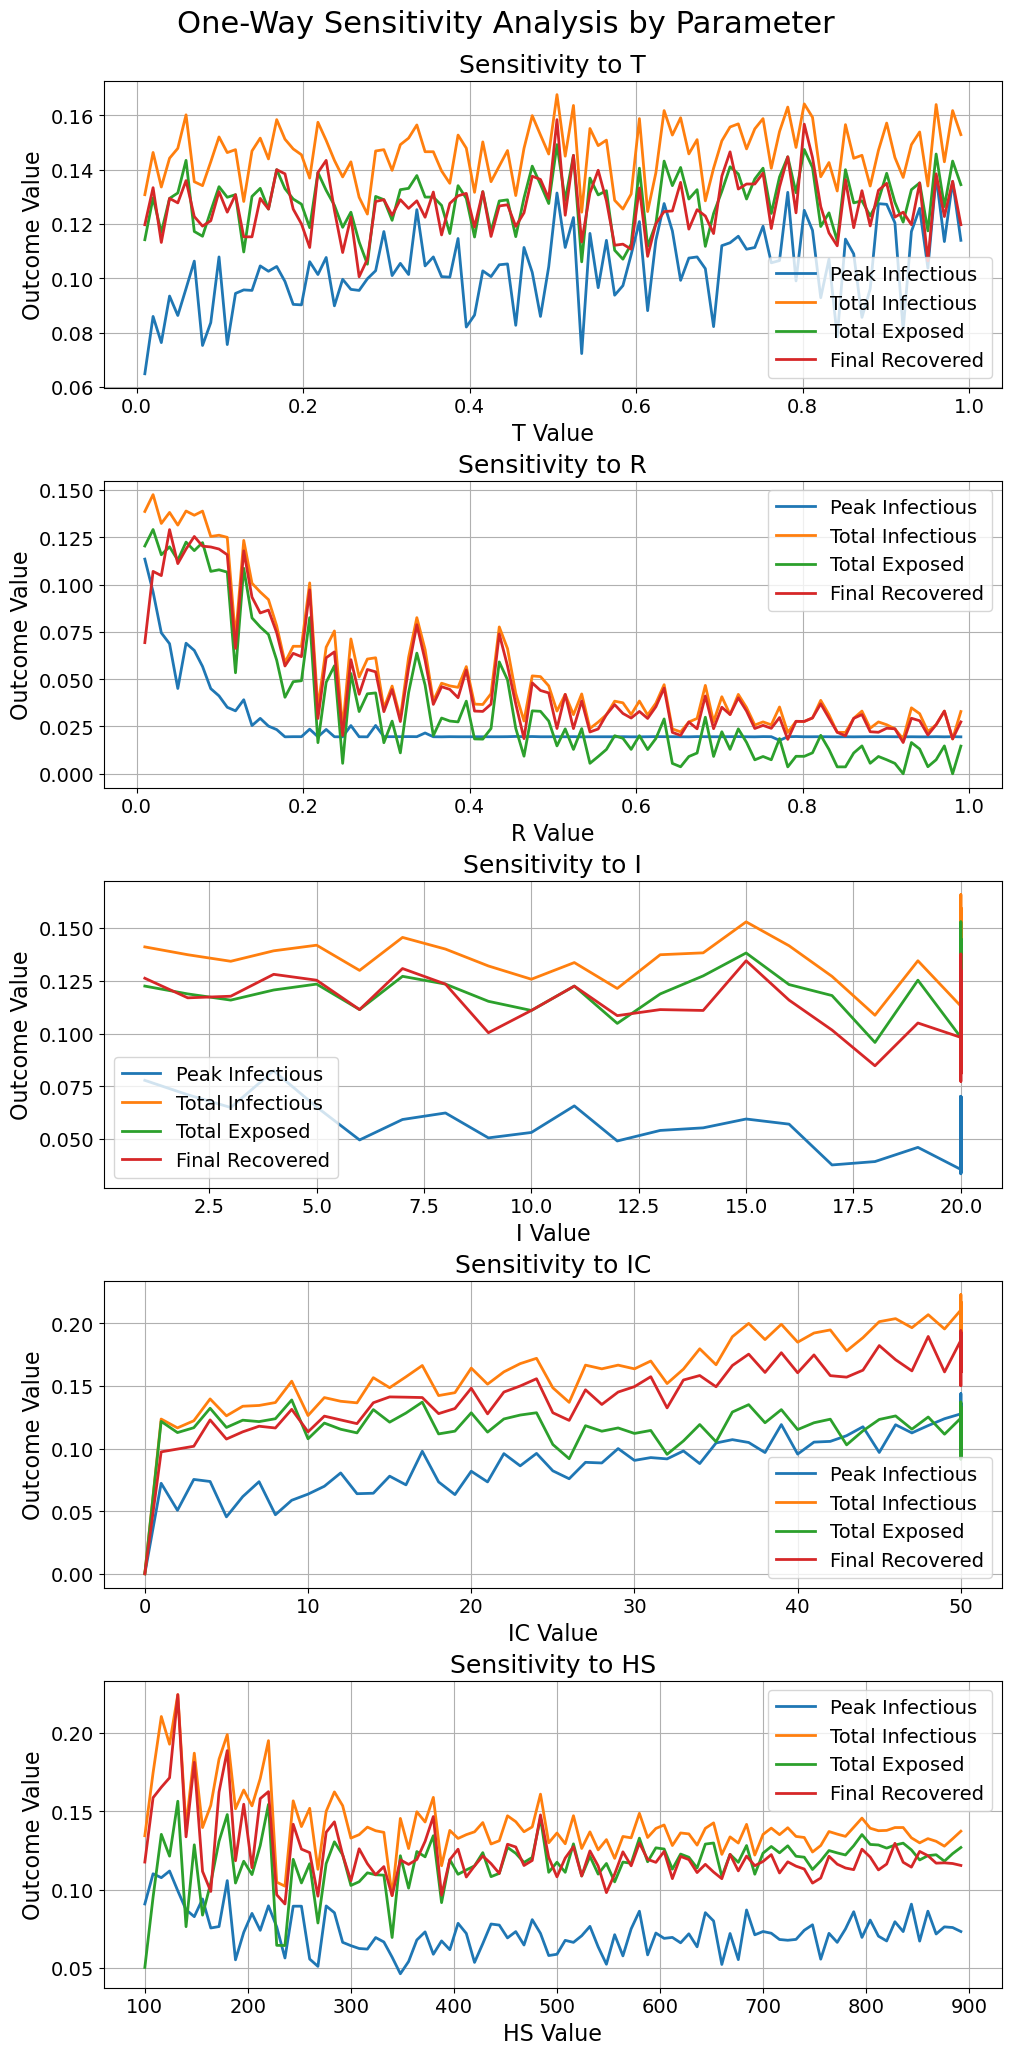

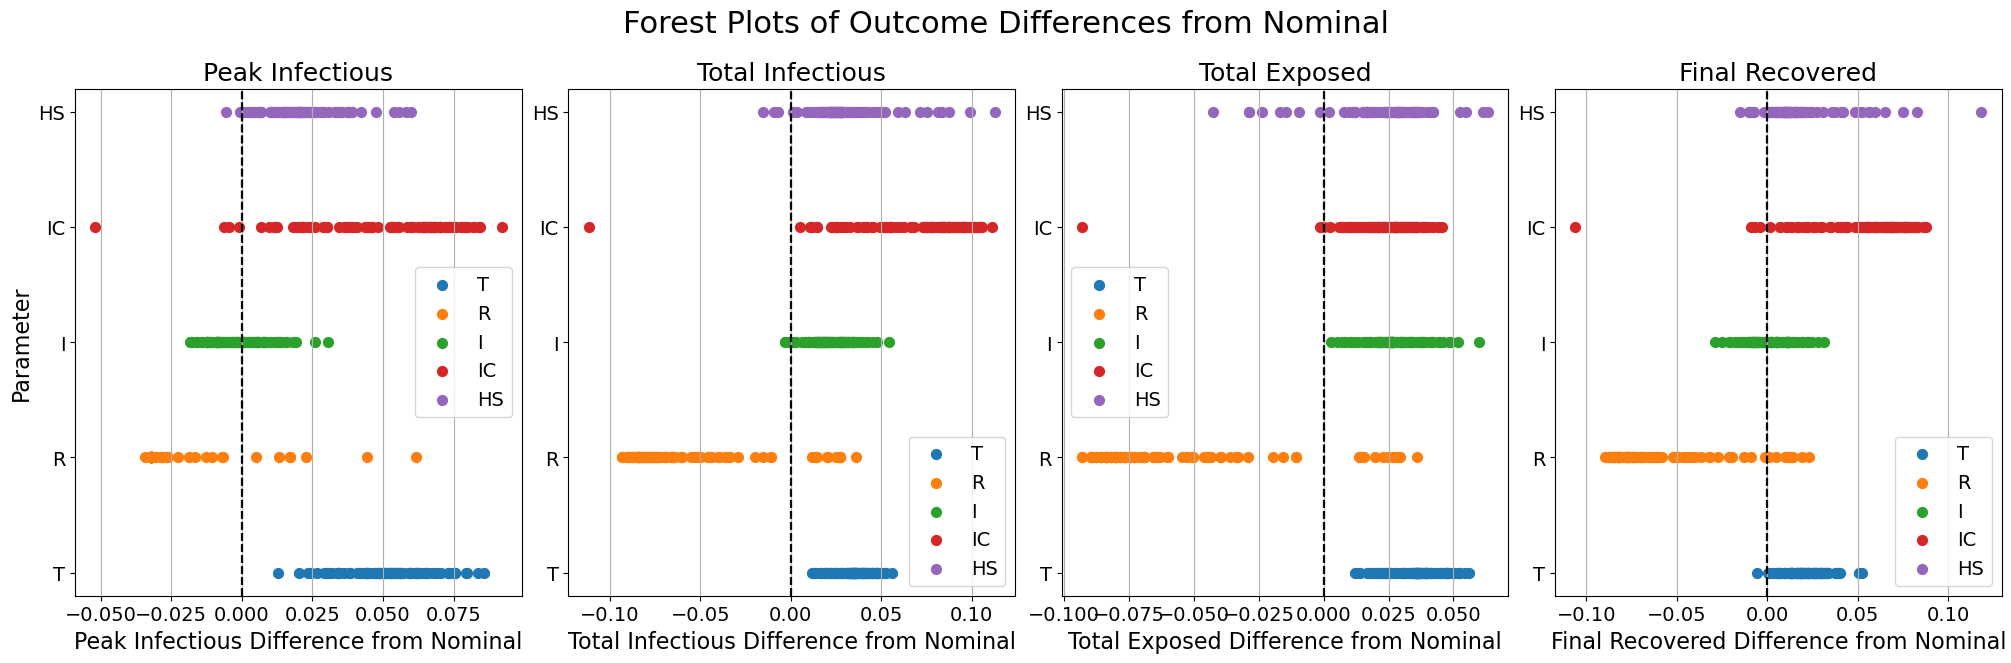


Sensitivity Summary (Min - Max (Range)):

          Peak Infectious       Total Infectious          Total Exposed  \
T   0.065 - 0.138 (0.073)  0.124 - 0.168 (0.044)  0.105 - 0.149 (0.044)   
R   0.018 - 0.114 (0.096)  0.018 - 0.148 (0.129)  0.000 - 0.129 (0.129)   
I   0.034 - 0.082 (0.049)  0.109 - 0.166 (0.057)  0.096 - 0.153 (0.057)   
IC  0.000 - 0.144 (0.144)  0.000 - 0.223 (0.223)  0.000 - 0.139 (0.139)   
HS  0.046 - 0.112 (0.066)  0.096 - 0.224 (0.128)  0.050 - 0.156 (0.106)   

          Final Recovered  
T   0.101 - 0.158 (0.058)  
R   0.017 - 0.129 (0.113)  
I   0.077 - 0.138 (0.060)  
IC  0.000 - 0.194 (0.194)  
HS  0.091 - 0.224 (0.134)  


In [9]:
plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 18, 'axes.labelsize': 16,
    'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14
})

fig, axes = plt.subplots(len(problem['names']), 1, figsize=(10, 4 * len(problem['names'])), constrained_layout=True)

for i, param in enumerate(problem['names']):
    ax = axes[i] if len(problem['names']) > 1 else axes
    for outcome in outcomes:
        ax.plot(param_ranges[param], results[outcome][param], label=outcome, linewidth=2)
    ax.set_title(f'Sensitivity to {param}')
    ax.set_xlabel(f'{param} Value')
    ax.set_ylabel('Outcome Value')
    ax.legend()
    ax.grid(True)

plt.suptitle('One-Way Sensitivity Analysis by Parameter', fontsize=22, y=1.02)
plt.savefig('param_wise_local_sensitivity.png', dpi = 300)
plt.show()



# Plotting: Forest Plots for Differences
fig, axes = plt.subplots(1, len(outcomes), figsize=(5 * len(outcomes), 6), constrained_layout=True)
if len(outcomes) == 1:
    axes = [axes]

for i, (outcome, ax) in enumerate(zip(outcomes, axes)):
    for j, param in enumerate(problem['names']):
        y = j  # Position on y-axis
        x = differences[outcome][param]  # Differences for this parameter
        ax.scatter(x, [y] * len(x), label=param, s=50)  # Plot points for each sampled value
        ax.axvline(0, color='k', linestyle='--', alpha=0.5)  # Line at zero difference

    ax.set_yticks(range(len(problem['names'])))
    ax.set_yticklabels(problem['names'])
    ax.set_xlabel(f'{outcome} Difference from Nominal')
    ax.set_title(f'{outcome}')
    ax.grid(True, axis='x')
    if i == 0:
        ax.set_ylabel('Parameter')
    ax.legend()

plt.suptitle('Forest Plots of Outcome Differences from Nominal', fontsize=22, y=1.08)
plt.savefig('forest_local_sensitivity.png', dpi = 300)
plt.show()

# Summary table
summary = pd.DataFrame(index=problem['names'], columns=outcomes)
for outcome in outcomes:
    for param in problem['names']:
        values = results[outcome][param]
        summary.loc[param, outcome] = f"{min(values):.3f} - {max(values):.3f} ({max(values) - min(values):.3f})"

print("\nSensitivity Summary (Min - Max (Range)):\n")
print(summary)

Differences from nominal values:

Peak Infectious:
  T: min=-0.005, max=0.048
  R: min=0.053, max=-0.032
  I: min=0.013, max=-0.012
  IC: min=-0.052, max=0.081
  HS: min=0.072, max=0.016

Total Infectious:
  T: min=0.019, max=0.025
  R: min=0.033, max=-0.079
  I: min=0.031, max=0.011
  IC: min=-0.112, max=0.091
  HS: min=0.052, max=0.024

Total Exposed:
  T: min=0.021, max=0.027
  R: min=0.035, max=-0.078
  I: min=0.035, max=0.019
  IC: min=-0.093, max=0.025
  HS: min=-0.016, max=0.033

Final Recovered:
  T: min=0.005, max=0.014
  R: min=-0.033, max=-0.077
  I: min=0.011, max=-0.012
  IC: min=-0.106, max=0.077
  HS: min=0.032, max=0.013


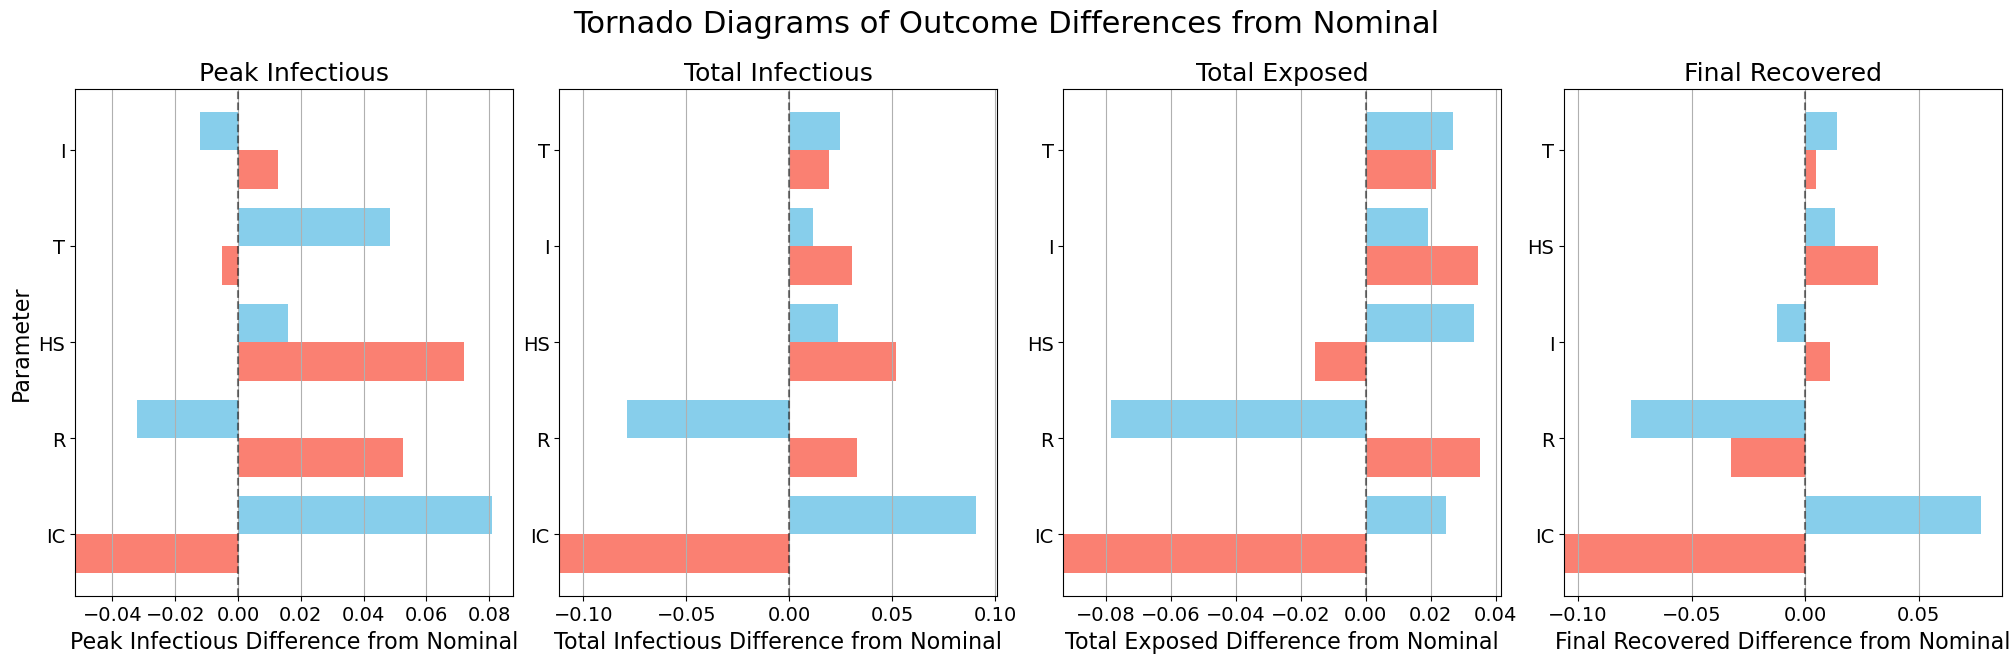

In [15]:
differences = {outcome: {param: {'min': 0.0, 'max': 0.0} for param in problem['names']} for outcome in outcomes}

for param_idx, param in enumerate(problem['names']):
    for bound_type, bound_value in [('min', problem['bounds'][param_idx][0]), 
                                   ('max', problem['bounds'][param_idx][1])]:
        # Ensure integer values for I, IC, HS
        if param in ['I', 'IC', 'HS']:
            bound_value = int(bound_value)
        # Create parameter set with nominal values, varying one parameter
        params = [nominal_params[name] if name != param else bound_value for name in problem['names']]
        # Run model
        try:
            output = model_wrapper(params)
            if not all(isinstance(x, (int, float)) and not np.isnan(x) for x in output):
                print(f"Invalid output for param {param}, bound {bound_type}: {output}")
                output = [0.0] * len(outcomes)
        except Exception as e:
            print(f"Error running model for param {param}, bound {bound_type}: {e}")
            output = [0.0] * len(outcomes)
        # Store differences
        for i, outcome in enumerate(outcomes):
            differences[outcome][param][bound_type] = output[i] - nominal_values[i]

# Debug: Print differences to verify data
print("Differences from nominal values:")
for outcome in outcomes:
    print(f"\n{outcome}:")
    for param in problem['names']:
        print(f"  {param}: min={differences[outcome][param]['min']:.3f}, max={differences[outcome][param]['max']:.3f}")

# Plotting: Tornado Diagrams
plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 18, 'axes.labelsize': 16,
    'xtick.labelsize': 14, 'ytick.labelsize': 14
})

fig, axes = plt.subplots(1, len(outcomes), figsize=(5 * len(outcomes), 6), constrained_layout=True)
if len(outcomes) == 1:
    axes = [axes]

for i, (outcome, ax) in enumerate(zip(outcomes, axes)):
    # Compute ranges for sorting
    param_ranges = []
    for param in problem['names']:
        min_diff = differences[outcome][param]['min']
        max_diff = differences[outcome][param]['max']
        if not (isinstance(min_diff, (int, float)) and isinstance(max_diff, (int, float))):
            print(f"Invalid differences for {outcome}, {param}: min={min_diff}, max={max_diff}")
            min_diff, max_diff = 0.0, 0.0
        range_val = abs(max_diff - min_diff)
        param_ranges.append((param, range_val))
    
    # Sort parameters by range (descending)
    param_ranges.sort(key=lambda x: x[1], reverse=True)
    sorted_params = [param for param, _ in param_ranges]

    # Prepare data for tornado plot
    y = np.arange(len(problem['names']))
    min_diffs = [differences[outcome][param]['min'] for param in sorted_params]
    max_diffs = [differences[outcome][param]['max'] for param in sorted_params]
    
    # Plot horizontal bars
    for j, param in enumerate(sorted_params):
        # Max difference (upper bar)
        max_val = max_diffs[j]
        ax.barh(y[j] + 0.2, abs(max_val), left=min(0, max_val), color='skyblue', height=0.4)
        # Min difference (lower bar)
        min_val = min_diffs[j]
        ax.barh(y[j] - 0.2, abs(min_val), left=min(0, min_val), color='salmon', height=0.4)

    ax.set_yticks(y)
    ax.set_yticklabels(sorted_params)
    ax.set_xlabel(f'{outcome} Difference from Nominal')
    ax.set_title(f'{outcome}')
    ax.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax.grid(True, axis='x')
    if i == 0:
        ax.set_ylabel('Parameter')

plt.suptitle('Tornado Diagrams of Outcome Differences from Nominal', fontsize=22, y=1.08)
plt.savefig('tornado_local_sensitivity.png', dpi = 300)
plt.show()